In [39]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

# Finding Contours as per usual

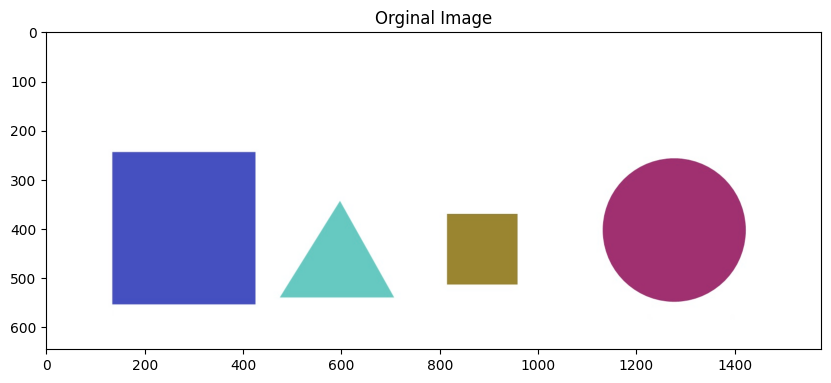

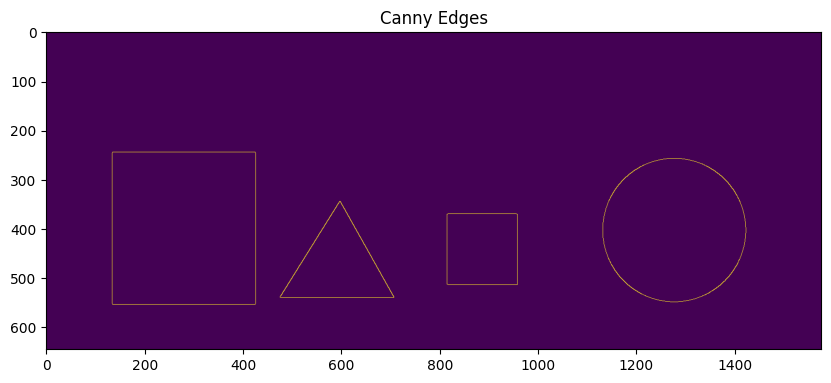

####################################################################################################


Number of contours found =  4


####################################################################################################


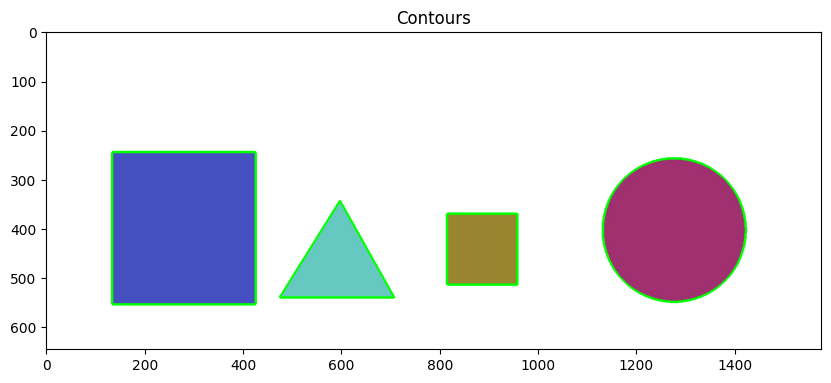

In [40]:
plt.figure(figsize=(10,5))
image=cv2.imread("/content/bunchofshapes.jpg")
plt.imshow(image)
plt.title("Orginal Image")
plt.show()

# grayscale our image
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
# find canny edges
edged=cv2.Canny(gray,50,200)
plt.figure(figsize=(10,5))
plt.imshow(edged)
plt.title("Canny Edges")
plt.show()

# find contours & print how many are found
print("#"*100)
print("\n")
contours,hierarchy=cv2.findContours(edged.copy(),cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_NONE)
print("Number of contours found = ",len(contours))
print("\n")
print("#"*100)

# draw all contours over blank image
cv2.drawContours(image,contours,-1,(0,255,0),3)
plt.figure(figsize=(10,5))
plt.imshow(image)
plt.title("Contours")
plt.show()

## **Sorting by Area using cv2.ContourArea and cv2.Moments**

![](https://github.com/rajeevratan84/ModernComputerVision/raw/main/moments.png)

Contours area before sorting : [20587.5, 22901.5, 66579.5, 90222.0]


Contours area after sorting : [90222.0, 66579.5, 22901.5, 20587.5]


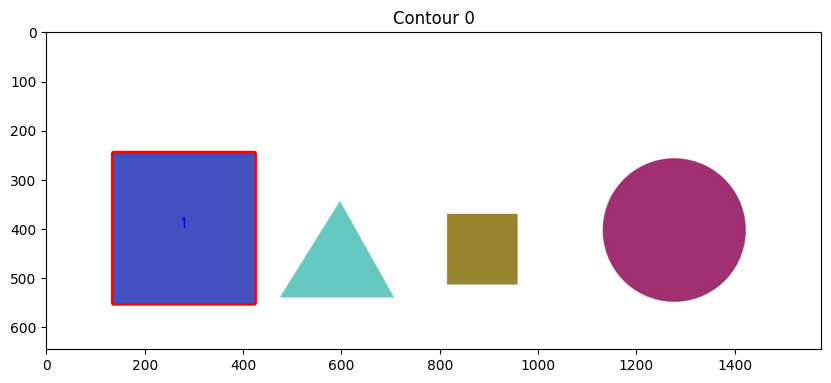

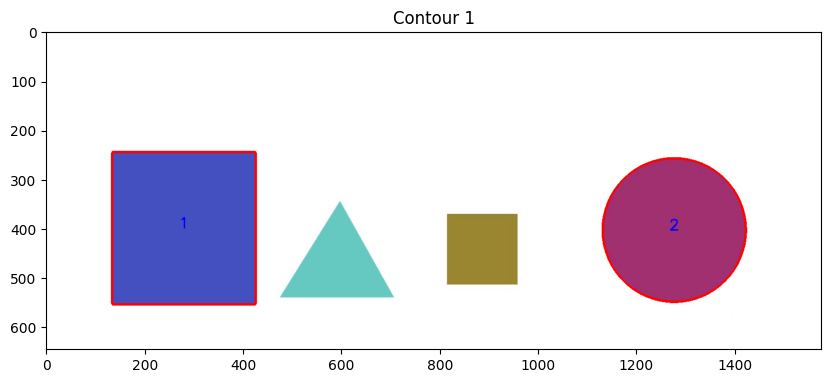

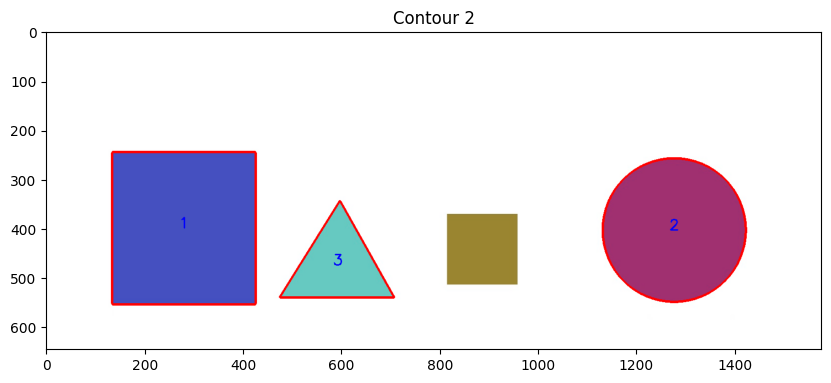

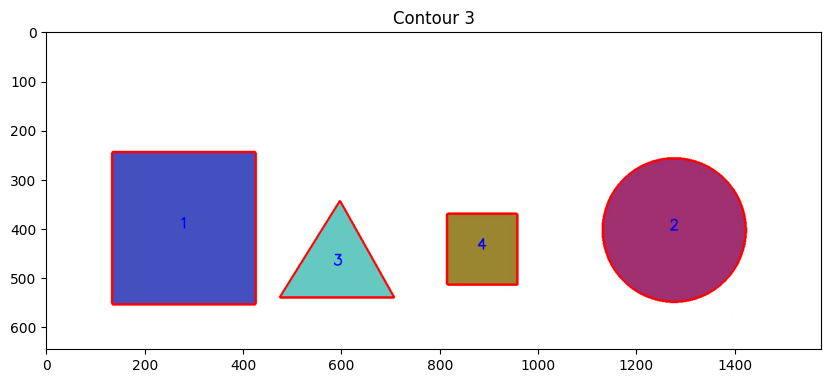

In [41]:
# function we'll use to display contour area

def get_contour_areas(contours):
  # returns the areas of all contours as list
  all_areas=[]
  for cnt in contours:
    area=cv2.contourArea(cnt)
    all_areas.append(area)
  return all_areas
# load image
image=cv2.imread("/content/bunchofshapes.jpg")
# print area of the contours before shorting
print(f"Contours area before sorting : {get_contour_areas(contours)}")
print("\n")
# sort contours large to small
sorted_contours=sorted(contours,key=cv2.contourArea,reverse=True)
# print area of the contours after sorting
print(f"Contours area after sorting : {get_contour_areas(sorted_contours)}")

# iterate over our contours and draw one at a time

for(i,c) in enumerate(sorted_contours):
  M=cv2.moments(c)
  cx=int(M['m10']/M['m00'])
  cy=int(M['m01']/M['m00'])
  cv2.putText(image,f"{i+1}",(cx-10,cy),cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2)
  cv2.drawContours(image,[c],-1,(255,0,0),3)
  plt.figure(figsize=(10,5))
  plt.imshow(image)
  plt.title(f"Contour {i}")
  plt.show()


# Define some functions we'll be using

In [42]:
def x_cord_contour(contours):
  # returns the X cordinate for the contour centroid
  if cv2.contourArea(contours)>10:
    M=cv2.moments(contours)
    return (int(M['m10']/M['m00']))
  else:
    pass


def label_contour_center(image,c):
  M=cv2.moments(c)
  cx=int(M['m10']/M['m00'])
  cy=int(M['m01']/M['m00'])
  cv2.circle(image,(cx,cy),10,(0,0,255),-1)
  return image

# We use Moments to Calculate the Center and then use the X Cordinate to sort from left to right

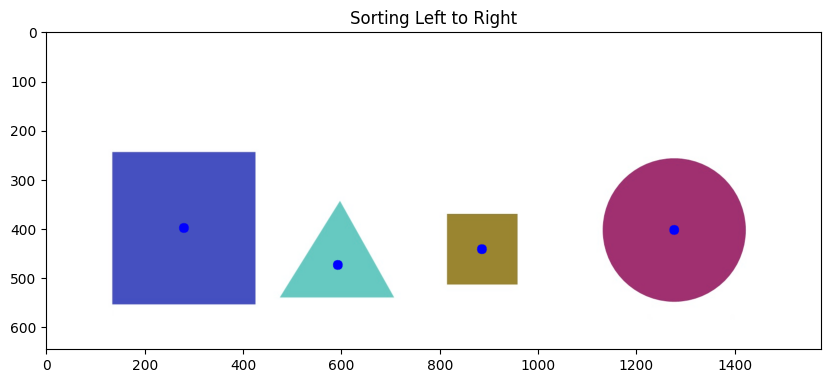

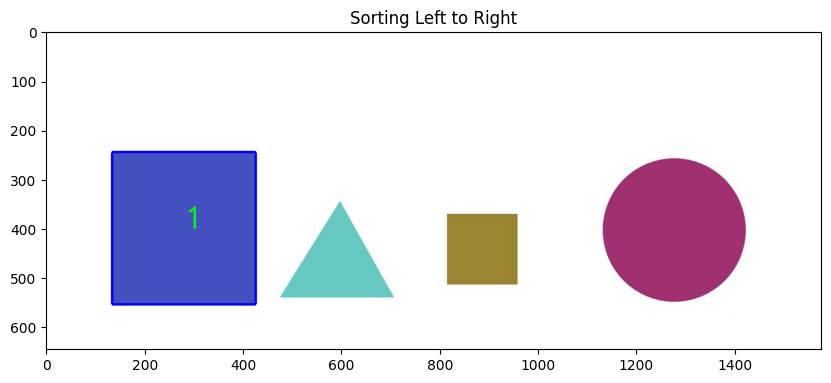

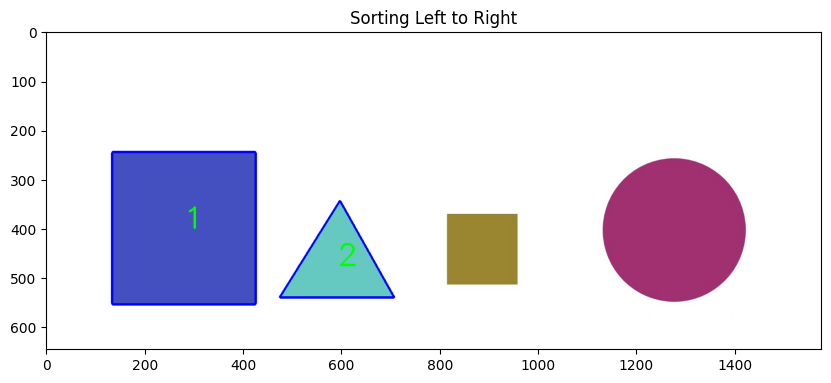

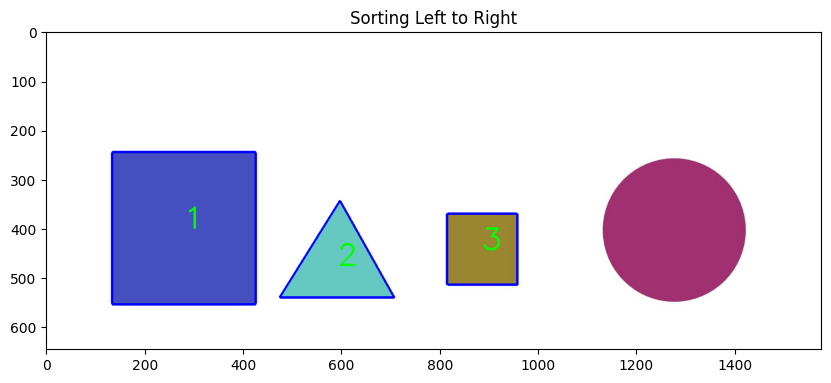

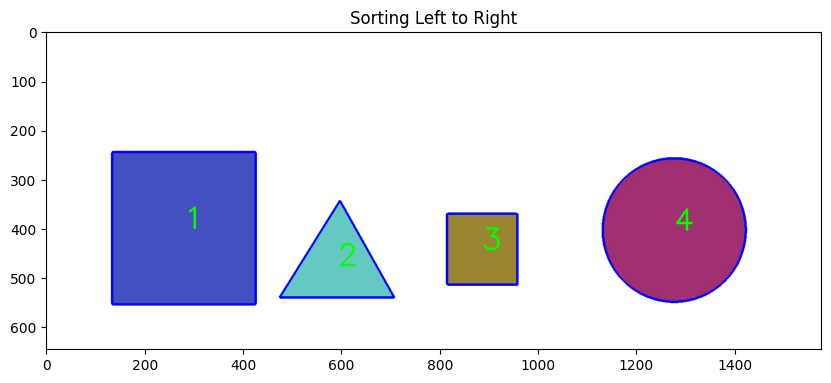

In [43]:
# load image
image=cv2.imread("/content/bunchofshapes.jpg")
orginal_image=image.copy()

# computer center of mass or centroids and draw them on our image

for (i,c) in enumerate(contours):
  original=label_contour_center(image,c)

plt.figure(figsize=(10,5))
plt.imshow(image)
plt.title("Sorting Left to Right")
plt.show()


# Sort by left to right using our x_cord_contour function
contours_left_to_right = sorted(contours, key = x_cord_contour, reverse = False)

# labeling contours left to right

for (i,c) in enumerate(contours_left_to_right):
  cv2.drawContours(orginal_image, [c], -1, (0,0,255),3)
  M=cv2.moments(c)
  cx=int(M['m10']/M['m00'])
  cy=int(M['m01']/M['m00'])
  cv2.putText(orginal_image, str(i+1), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX,2, (0, 255, 0), 3)
  plt.figure(figsize=(10,5))
  plt.imshow(orginal_image)
  plt.title("Sorting Left to Right")
  plt.show()

## **Approximating Contours using ApproxPolyDP**

### **Using ApproxPolyDP to approximate contours as a more defined shape**
It approximates a contour shape to another shape with less number of vertices depending upon the precision we specify.


***cv2.approxPolyDP(contour, Approximation Accuracy, Closed)***
- **contour** – is the individual contour we wish to approximate
- **Approximation Accuracy** – Important parameter is determining the accuracy of the approximation. Small values give precise-  approximations, large values give more generic approximation. A good rule of thumb is less than 5% of the contour perimeter
- **Closed** – a Boolean value that states whether the approximate contour should be open or closed


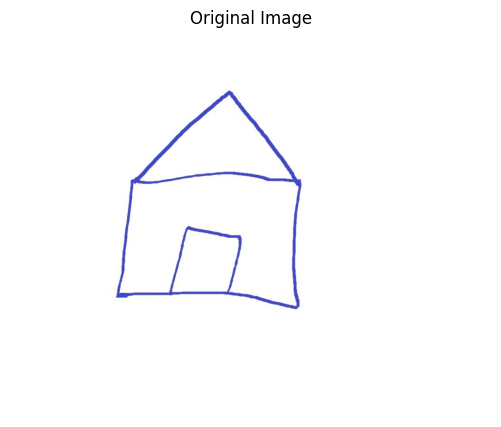

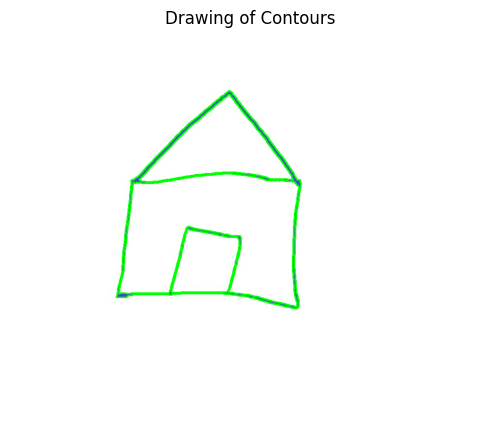

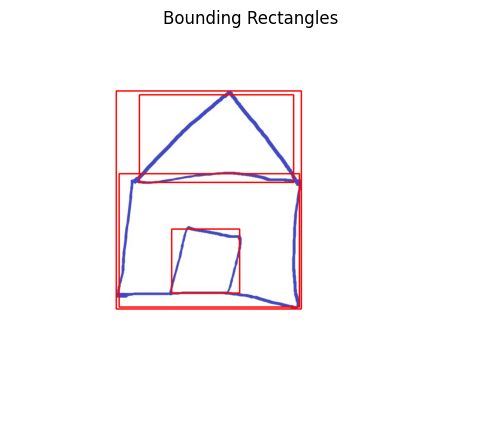

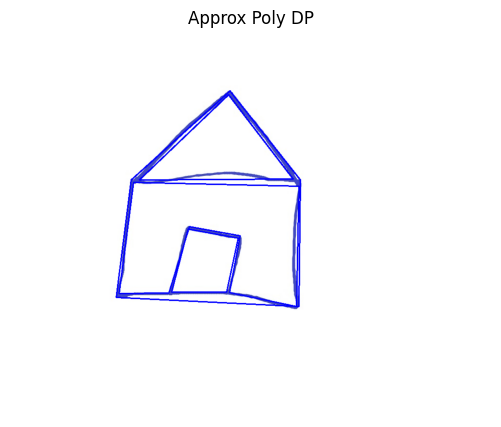

In [44]:

# Load image and keep a copy
image = cv2.imread('/content/house.jpg')
orig_image = image.copy()

# Display Original Image
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(orig_image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()

# Convert to grayscale and binarize
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# Find contours
contours, hierarchy = cv2.findContours(thresh.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

# Copy images for different contour visualizations
contour_img = orig_image.copy()
bounding_rect_img = orig_image.copy()
approx_poly_img = orig_image.copy()

# Draw bounding rectangles and contours
for c in contours:
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(bounding_rect_img, (x, y), (x + w, y + h), (0, 0, 255), 2)  # Red rectangles
    cv2.drawContours(contour_img, [c], 0, (0, 255, 0), 2)  # Green contours

# Display Contours and Bounding Rectangles
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.title('Drawing of Contours')
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(bounding_rect_img, cv2.COLOR_BGR2RGB))
plt.title('Bounding Rectangles')
plt.axis('off')
plt.show()

# Approximate contours using Polygonal Curve Approximation
for c in contours:
    accuracy = 0.03 * cv2.arcLength(c, True)  # Adjust accuracy
    approx = cv2.approxPolyDP(c, accuracy, True)
    cv2.drawContours(approx_poly_img, [approx], 0, (255, 0, 0), 2)  # Blue approx polygons

# Display Approximate Polygonal Contours
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(approx_poly_img, cv2.COLOR_BGR2RGB))
plt.title('Approx Poly DP')
plt.axis('off')
plt.show()


# **Convex Hull**

![](https://github.com/rajeevratan84/ModernComputerVision/raw/main/convex.png)

Convex Hull will look similar to contour approximation, but it is not (Both may provide the same results in some cases).

The cv2.convexHull() function checks a curve for convexity defects and corrects it. Generally speaking, convex curves are the curves which are always bulged out, or at-least flat. And if it is bulged inside, it is called convexity defects. For example, check the below image of hand. Red line shows the convex hull of hand. The double-sided arrow marks shows the convexity defects, which are the local maximum deviations of hull from contours

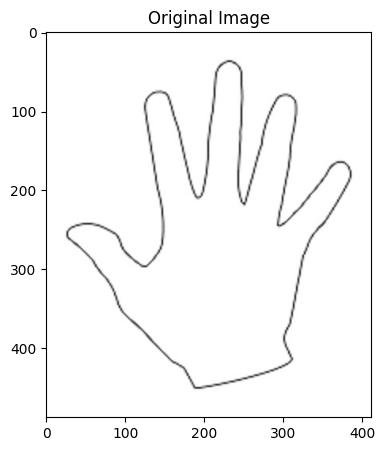

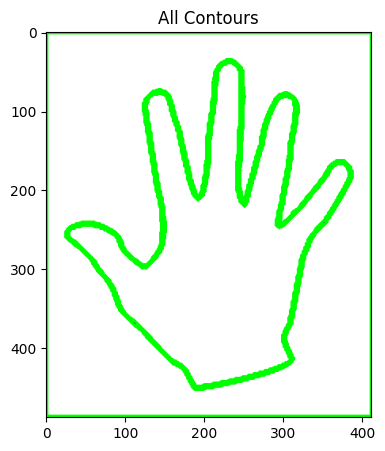

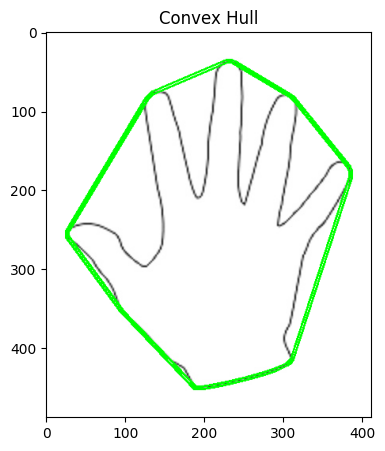

In [45]:
image=cv2.imread("/content/hand.jpg")
original_image=image.copy()
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.show()

# threshold the image
ret,thresh=cv2.threshold(gray,176,255,0)
# find contours
contours,hierarchy=cv2.findContours(thresh.copy(),cv2.RETR_LIST,cv2.CHAIN_APPROX_NONE)
cv2.drawContours(image,contours,-1,(0,255,0),3)
plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.title("All Contours")
plt.show()

# sort contours by area and then remove the largest frame contour

n=len(contours)-1
contours=sorted(contours,key=cv2.contourArea,reverse=False)[:n]

# iterate through contours and draw the convex hull
for c in contours:
  hull=cv2.convexHull(c)
  cv2.drawContours(original_image,[hull],0,(0,255,0),2)

plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(original_image,cv2.COLOR_BGR2RGB))
plt.title("Convex Hull")
plt.show()

# **Matching Contours**
## **cv2.matchShapes(contour template, contour, method, method parameter)**

**Output** – match value (lower values means a closer match)

- Contour Template – This is our reference contour that we’re trying to find in the new image
- Contour – The individual contour we are checking against
- Method – Type of contour matching (1, 2, 3)
- Method Parameter – leave alone as 0.0 (not fully utilized in python OpenCV)

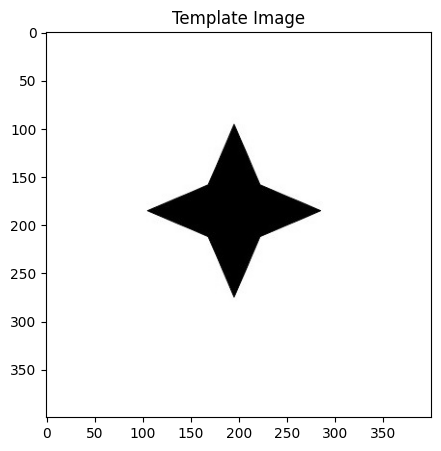

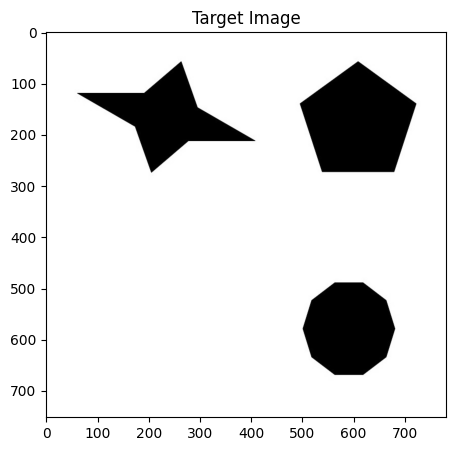

0.13081816783853514
0.15902005339788694
0.14987915682525596
0.07094034474475601


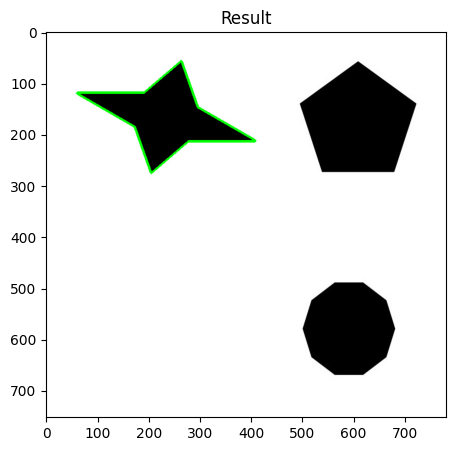

In [46]:
template=cv2.imread("/content/4star.jpg",0)
plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(template,cv2.COLOR_BGR2RGB))
plt.title("Template Image")
plt.show()
print("\n")
# load target image with shapes w're trying to match
target=cv2.imread("/content/shapestomatch.jpg")
target_gray=cv2.cvtColor(target,cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(target,cv2.COLOR_BGR2RGB))
plt.title("Target Image")
plt.show()

# threshold both images first before using cv.findcontours

ret,thresh1=cv2.threshold(template,127,255,0)
ret,thresh2=cv2.threshold(target_gray,127,255,0)



# Find contours in template
contours, hierarchy = cv2.findContours(thresh1, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

# We need to sort the contours by area so that we can remove the largest
# contour which is the image outline
sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

# We extract the second largest contour which will be our template contour
template_contour = contours[1]

# Extract contours from second target image
contours, hierarchy = cv2.findContours(thresh2, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

for c in contours:
    # Iterate through each contour in the target image and
    # use cv2.matchShapes to compare contour shapes
    match = cv2.matchShapes(template_contour, c, 3, 0.0)

    print(match)
    if match < 0.15:
        closest_contour = c
    else:
        closest_contour = []

cv2.drawContours(target, [closest_contour], -1, (0, 255, 0), 3)
plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(target,cv2.COLOR_BGR2RGB))
plt.title("Result")
plt.show()